# Simple Linear Regression

This notebook demonstrates Simple Linear Regression using the PlacementPredict dataset.

### Objective
To predict a dependent variable using one independent variable and understand the relationship between them.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv('../data/placement_predict_50k Dataset_final.csv')

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (50000, 32)


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,0,66.7,2.2,49.4,47.8,0,Low,0,0,0.00
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,0,48.2,2.4,26.7,25.8,0,Low,0,0,0.00
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,0,73.8,2.8,67.7,41.5,0,Low,1,0,3.89
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,0,69.8,2.7,66.9,48.0,0,Mid,1,0,8.37
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,1,73.1,2.1,71.7,61.7,1,High,1,0,18.99


In [3]:
X = df[["CGPA"]]
y = df["Salary Package"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 1)
y shape: (50000,)


In [4]:
placed_df = df[df["Salary Package"] > 0].copy()

print("Placed students with Salary Package > 0:", len(placed_df))

Placed students with Salary Package > 0: 32924


In [5]:
X = placed_df[["CGPA"]]
y = placed_df["Salary Package"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (32924, 1)
y shape: (32924,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 26339
Testing samples : 6585


In [7]:
model = LinearRegression()

#Training the model with training data
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

Intercept: -18.41694534995241
Coefficient: 4.110017173036385


In [8]:
y_train_pred = model.predict(X_train)

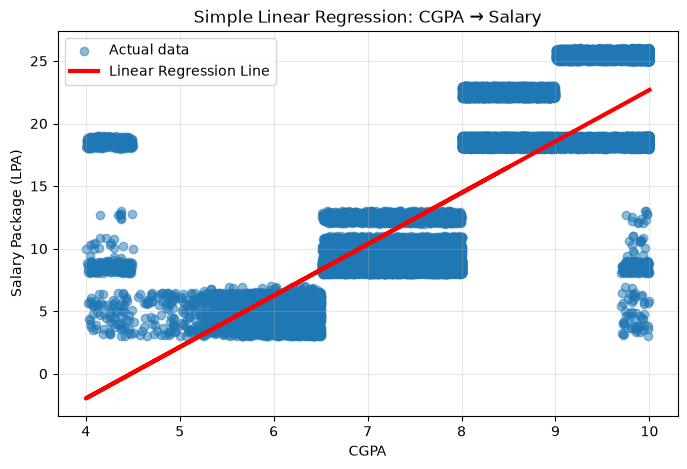

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    X_train["CGPA"],
    y_train,
    alpha=0.5,
    label="Actual data"
)

plt.plot(
    X_train["CGPA"],
    y_train_pred,
    color="red",
    linewidth=3,
    label="Linear Regression Line"
)

plt.xlabel("CGPA")
plt.ylabel("Salary Package (LPA)")
plt.title("Simple Linear Regression: CGPA → Salary")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
y_test_pred = model.predict(X_test)

In [11]:
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

In [12]:
# Give a new student's CGPA
new_cgpa = float(input("Enter CGPA: "))

# Predict salary
predicted_salary = model.predict([[new_cgpa]])[0]

print(f"Predicted Salary Package: {predicted_salary:.2f} LPA")

Predicted Salary Package: 18.16 LPA


/Users/poojithamusunuri/Documents/Machine Learning/.MLvenv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
